--- Dataset Shape ---
Rows: 200, Columns: 4

--- First 5 Rows ---
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

--- Missing Values ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

--- Summary Statistics ---
           count      mean        std  min     25%     50%      75%    max
TV         200.0  147.0425  85.854236  0.7  74.375  149.75  218.825  296.4
Radio      200.0   23.2640  14.846809  0.0   9.975   22.90   36.525   49.6
Newspaper  200.0   30.5540  21.778621  0.3  12.750   25.75   45.100  114.0
Sales      200.0   14.0225   5.217457  1.6  10.375   12.90   17.400   27.0


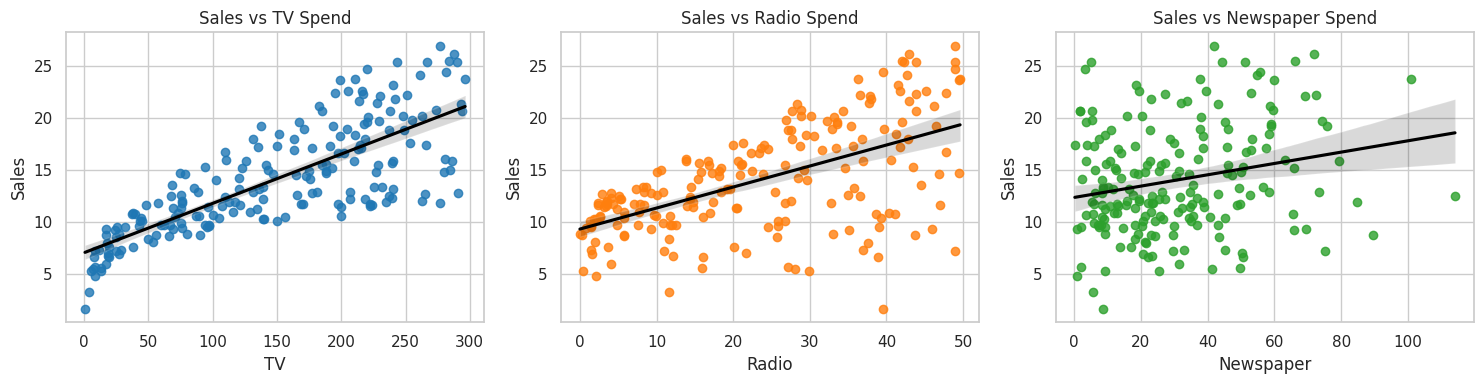

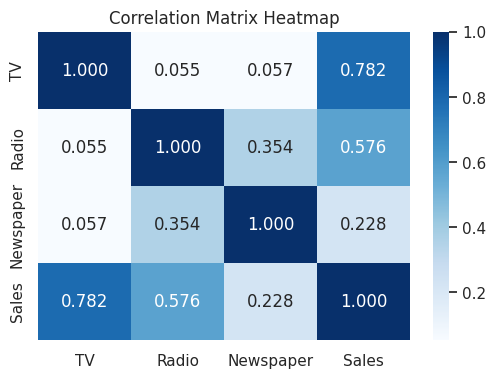


================ MODEL PERFORMANCE ================
--- Linear Regression (Baseline) ---
MAE:      1.4608
RMSE:     1.7816
R² Score: 0.8994 (89.94% variance explained)

--- Random Forest Regressor ---
MAE:      0.6201
RMSE:     0.7686
R² Score: 0.9813 (98.13% variance explained)



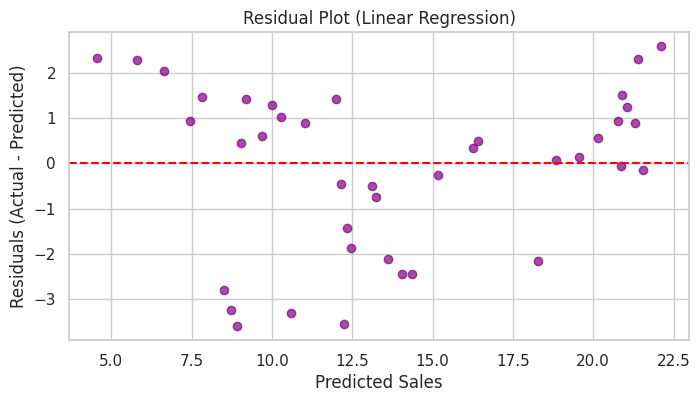

--- Channel Impact on Sales (Coefficients) ---
  Channel  Coefficient
    Radio     0.189195
       TV     0.044730
Newspaper     0.002761

Intercept: 2.9791


In [3]:
"""
Oasis Infobyte - Data Science Internship
Task 5: Sales Prediction Using Python
Author: Shivam Umesh Jaiswal
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. LOAD DATASET & INITIAL INSPECTION
# ==========================================
# Advertising budget vs sales benchmark dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)

# Drop index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Standardize column names to Title Case to match expected code names ('TV', 'Radio', 'Newspaper', 'Sales')
df.columns = df.columns.str.capitalize().str.replace('Tv', 'TV')

print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe().T)

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
sns.set_theme(style="whitegrid")

# Scatter plots: Sales vs each advertising channel
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channels = ['TV', 'Radio', 'Newspaper']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, channel, col in zip(axes, channels, colors):
    sns.regplot(x=channel, y='Sales', data=df, ax=ax, color=col, line_kws={'color': 'black'})
    ax.set_title(f"Sales vs {channel} Spend")
plt.tight_layout()
plt.show()

# Correlation Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.3f')
plt.title("Correlation Matrix Heatmap")
plt.show()

# ==========================================
# 3. TRAIN / TEST SPLIT
# ==========================================
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ==========================================
# 4. MODEL TRAINING & COMPARISON
# ==========================================
# Baseline Model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Alternative Non-Linear Model: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

def evaluate_regressor(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    print(f"R² Score: {r2:.4f} ({r2 * 100:.2f}% variance explained)\n")
    return mae, rmse, r2

print("\n================ MODEL PERFORMANCE ================")
evaluate_regressor("Linear Regression (Baseline)", y_test, y_pred_lr)
evaluate_regressor("Random Forest Regressor", y_test, y_pred_rf)

# ==========================================
# 5. RESIDUAL PLOT (Best Model: Random Forest / LR)
# ==========================================
residuals = y_test - y_pred_lr

plt.figure(figsize=(8, 4))
plt.scatter(y_pred_lr, residuals, color='purple', alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot (Linear Regression)")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

# ==========================================
# 6. CHANNEL IMPACT ANALYSIS (COEFFICIENTS)
# ==========================================
coeff_df = pd.DataFrame({
    'Channel': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print("--- Channel Impact on Sales (Coefficients) ---")
print(coeff_df.to_string(index=False))
print(f"\nIntercept: {lr.intercept_:.4f}")